In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import tensorflow as tf

# Data parameters
data_dir = 'Rice_Image_Dataset'
batch_size = 256
img_height = 224
img_width = 224
total_images = 75000

# Load the full dataset
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    shuffle=True,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Save the class names before any splitting/transformations
class_names = full_ds.class_names

# Calculate counts for splits
train_count = int(0.8 * total_images)   # 60,000 images
val_count   = int(0.1 * total_images)     # 7,500 images
# Remaining images will be used for testing: 7,500 images

# Number of batches (approximate)
train_batches = train_count // batch_size
val_batches   = val_count // batch_size

# Split the dataset
train_ds = full_ds.take(train_batches)
remaining_ds = full_ds.skip(train_batches)
val_ds = remaining_ds.take(val_batches)
test_ds = remaining_ds.skip(val_batches)

# Optimize datasets with caching and prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 75000 files belonging to 5 classes.


## Visualize the Data

2025-03-09 08:31:46.747367: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [75000]
	 [[{{node Placeholder/_0}}]]
2025-03-09 08:31:46.747557: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [75000]
	 [[{{node Placeholder/_4}}]]
2025-03-09 08:31:46.751893: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2025-03-09 08:31:47.012453: W tensorflow/core/kernels/data/cache_dataset_ops.cc:856] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation 

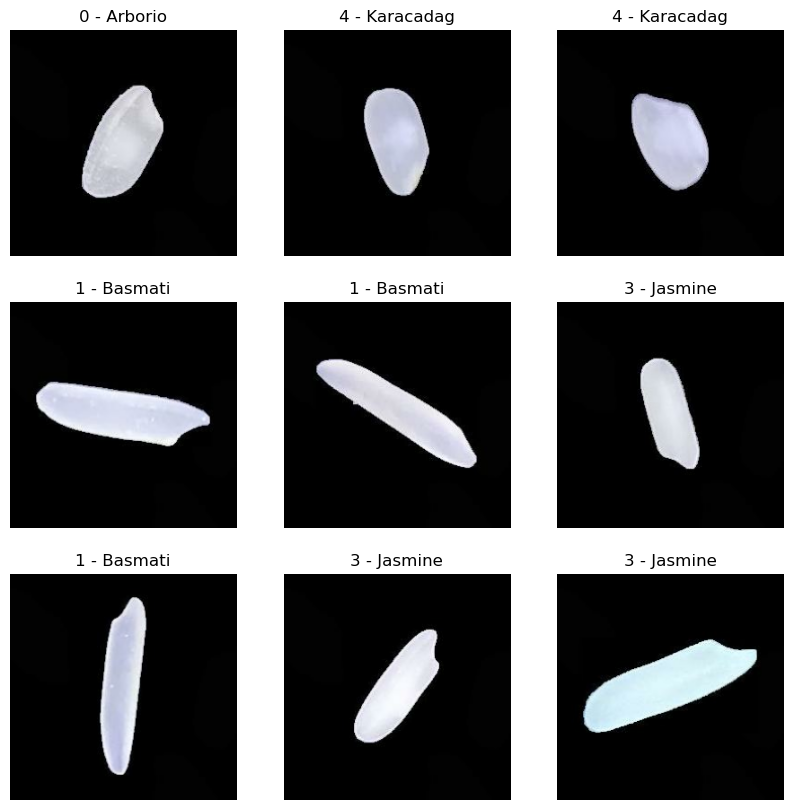

In [3]:
import matplotlib.pyplot as plt

# Display a grid of images from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        # Display the label number and corresponding class name (e.g., "0 - Arborio")
        label_val = labels[i].numpy()
        plt.title(f"{label_val} - {class_names[label_val]}")
        plt.axis("off")
plt.savefig('training_images.jpg', format='jpg', dpi=300)
plt.show()

# Models

## Transfer Learning Model

In [4]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# Transfer Learning Model: Using a pre-trained MobileNetV2 as an example
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze the base model

# Add a classification head on top
global_avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(5, activation='softmax')(global_avg)  # 5 classes for rice varieties

model = tf.keras.Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Set up EarlyStopping callback to monitor validation loss and stop training if it doesn't improve
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model using training and validation sets, with early stopping included
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,  # Adjust as needed
    callbacks=[early_stop]
)

# Print the model summary for a quick review of the architecture
model.summary()

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/10


2025-03-09 08:31:47.792927: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [75000]
	 [[{{node Placeholder/_0}}]]
2025-03-09 08:31:47.793110: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [75000]
	 [[{{node Placeholder/_0}}]]


234/234 [==============================] - ETA: 0s - loss: 0.3309 - accuracy: 0.9022

2025-03-09 08:36:55.207346: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [75000]
	 [[{{node Placeholder/_0}}]]
2025-03-09 08:36:55.207540: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [75000]
	 [[{{node Placeholder/_4}}]]


234/234 [==============================] - 354s 2s/step - loss: 0.3309 - accuracy: 0.9022 - val_loss: 0.1542 - val_accuracy: 0.9573
Epoch 2/10
234/234 [==============================] - 349s 1s/step - loss: 0.1283 - accuracy: 0.9632 - val_loss: 0.1101 - val_accuracy: 0.9675
Epoch 3/10
234/234 [==============================] - 356s 2s/step - loss: 0.1003 - accuracy: 0.9692 - val_loss: 0.0930 - val_accuracy: 0.9716
Epoch 4/10
234/234 [==============================] - 358s 2s/step - loss: 0.0865 - accuracy: 0.9729 - val_loss: 0.0838 - val_accuracy: 0.9743
Epoch 5/10
234/234 [==============================] - 357s 2s/step - loss: 0.0779 - accuracy: 0.9752 - val_loss: 0.0778 - val_accuracy: 0.9743
Epoch 6/10
234/234 [==============================] - 356s 2s/step - loss: 0.0719 - accuracy: 0.9768 - val_loss: 0.0735 - val_accuracy: 0.9749
Epoch 7/10
234/234 [==============================] - 351s 2s/step - loss: 0.0674 - accuracy: 0.9782 - val_loss: 0.0701 - val_accuracy: 0.9762
Epoch 8/10

2025-03-09 09:30:58.847408: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [75000]
	 [[{{node Placeholder/_0}}]]
2025-03-09 09:30:58.848513: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [75000]
	 [[{{node Placeholder/_4}}]]


30/30 [==============================] - 50s 1s/step - loss: 0.0577 - accuracy: 0.9831
Test accuracy: 0.9831


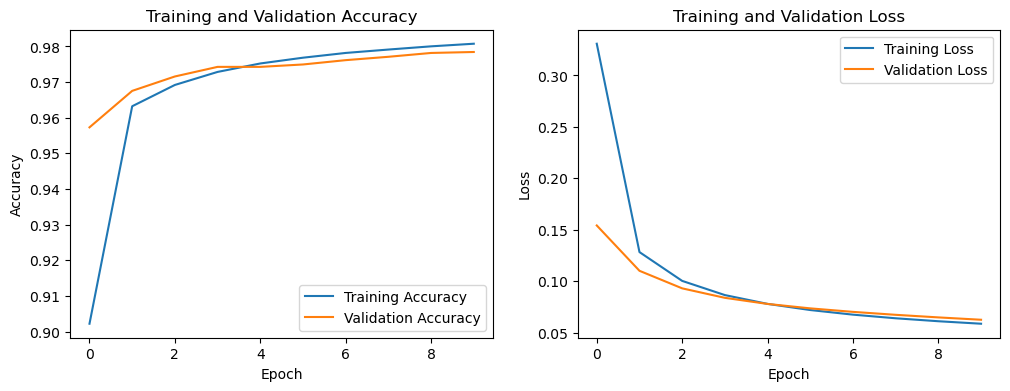

In [5]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('transfer_learning_accuracy.jpg', format='jpg', dpi=300)
plt.show()


2025-03-09 09:31:49.373122: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [75000]
	 [[{{node Placeholder/_4}}]]
2025-03-09 09:31:49.373456: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [75000]
	 [[{{node Placeholder/_0}}]]


8/8 [==============================] - 2s 178ms/step


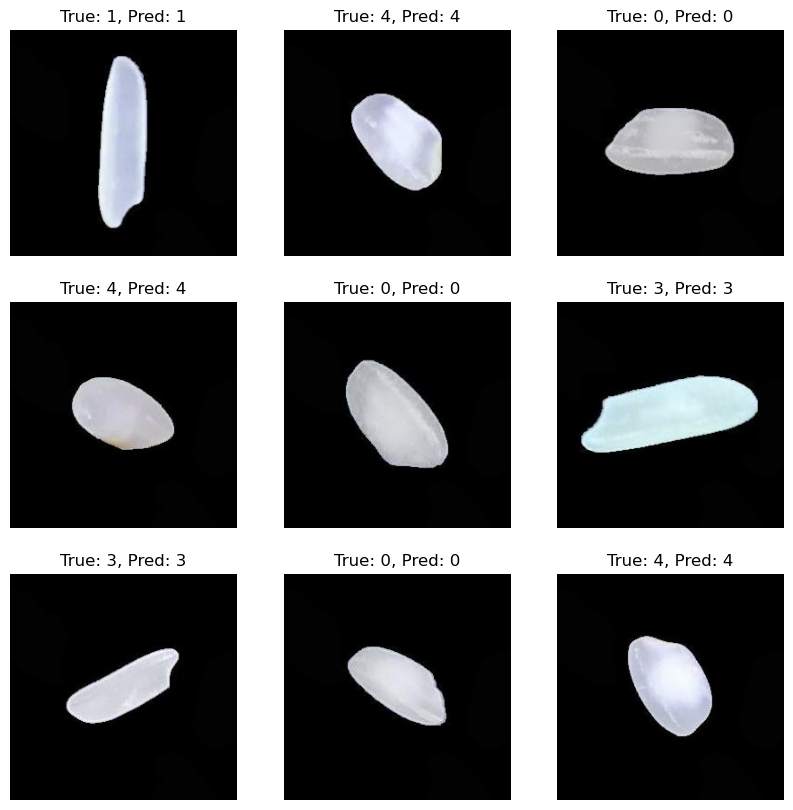

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from the validation dataset
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {labels[i].numpy()}, Pred: {predicted_labels[i]}")
        plt.axis("off")
    plt.savefig('transfer_learning_results.jpg', format='jpg', dpi=300)
    plt.show()


8/8 [==============================] - 1s 148ms/step


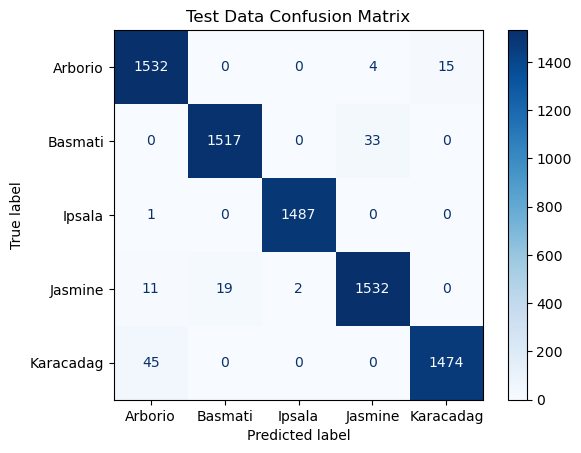

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions and true labels from the validation set
all_preds = []
all_labels = []
for images, labels in test_ds:
    preds = model.predict(images)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Test Data Confusion Matrix")
plt.savefig('transfer_learning_matrix.jpg', format='jpg', dpi=300)
plt.show()


## CNN Base Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define image dimensions and batch size (adjust as needed)
img_height = 224
img_width = 224
batch_size = 256

# Build a baseline CNN model
model = Sequential([
    # Convolutional block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D((2, 2)),
    
    # Convolutional block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Convolutional block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Classification head
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Helps reduce overfitting
    Dense(5, activation='softmax')  # 5 output classes for your rice varieties
])

# Compile the model with an appropriate optimizer and loss function
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Set up an EarlyStopping callback to stop training if validation loss doesn't improve
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model using the training and validation datasets
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,  # Adjust the number of epochs as needed
    callbacks=[early_stop]
)

# Print the model summary for a quick review of the architecture
model.summary()

# Calculate loss/accuracy
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/10
234/234 [==============================] - 897s 4s/step - loss: 2.9697 - accuracy: 0.9081 - val_loss: 0.0833 - val_accuracy: 0.9752
Epoch 2/10
234/234 [==============================] - 908s 4s/step - loss: 0.1185 - accuracy: 0.9597 - val_loss: 0.0711 - val_accuracy: 0.9779
Epoch 3/10
234/234 [==============================] - 921s 4s/step - loss: 0.0914 - accuracy: 0.9697 - val_loss: 0.0630 - val_accuracy: 0.9806
Epoch 4/10
234/234 [==============================] - 923s 4s/step - loss: 0.0733 - accuracy: 0.9760 - val_loss: 0.0583 - val_accuracy: 0.9825
Epoch 5/10
234/234 [==============================] - 924s 4s/step - loss: 0.0601 - accuracy: 0.9790 - val_loss: 0.0547 - val_accuracy: 0.9838
Epoch 6/10
234/234 [==============================] - 915s 4s/step - loss: 0.0491 - accuracy: 0.9834 - val_loss: 0.0429 - val_accuracy: 0.9880
Epoch 7/10
234/234 [==============================] - 897s 4s/step - loss: 0.0380 - accuracy: 0.9873 - val_loss: 0.0382 - val_accuracy: 0.9887

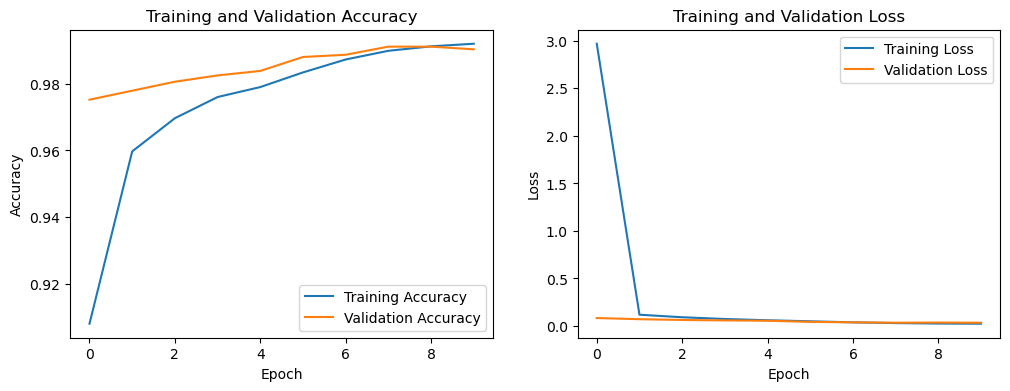

In [10]:
# Assuming `history` is the output from model.fit
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('cnn_accuracy.jpg', format='jpg', dpi=300)
plt.show()


2025-03-09 13:29:08.645758: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [75000]
	 [[{{node Placeholder/_4}}]]
2025-03-09 13:29:08.646383: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [75000]
	 [[{{node Placeholder/_0}}]]


8/8 [==============================] - 1s 109ms/step


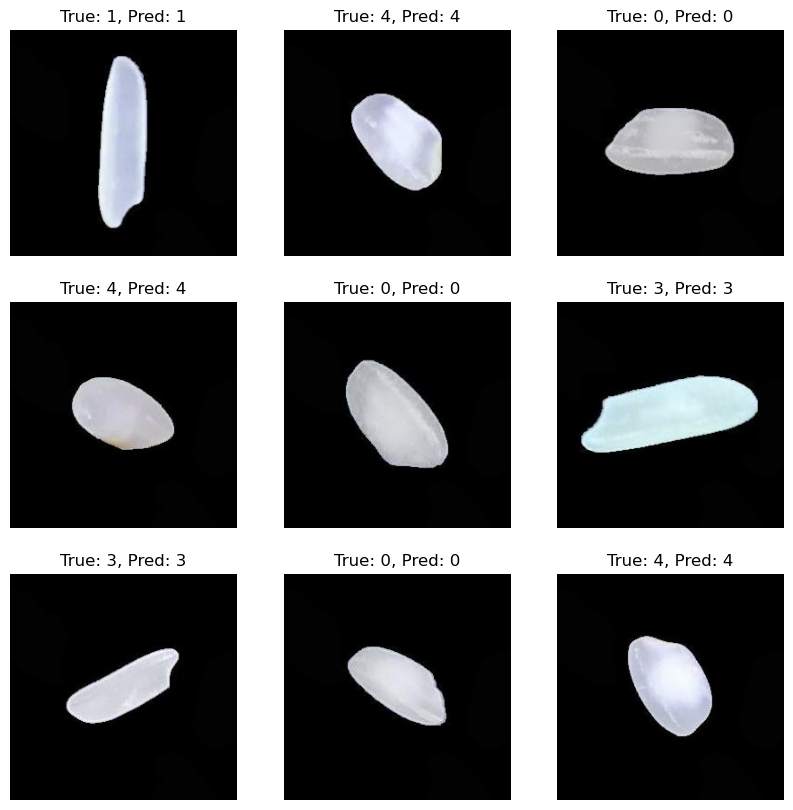

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from the validation dataset
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {labels[i].numpy()}, Pred: {predicted_labels[i]}")
        plt.axis("off")
    plt.savefig('cnn_results.jpg', format='jpg', dpi=300)
    plt.show()


8/8 [==============================] - 1s 101ms/step


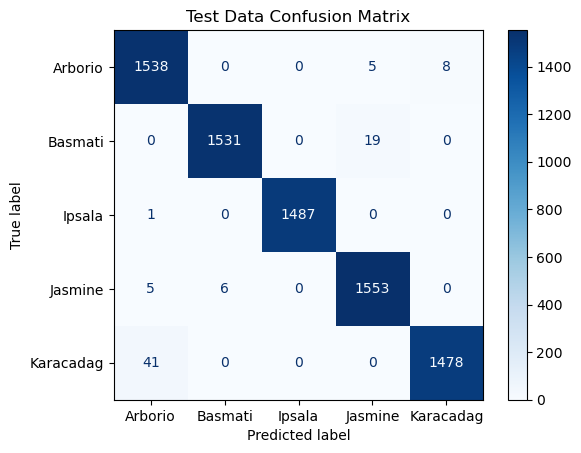

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions and true labels from the validation set
all_preds = []
all_labels = []
for images, labels in test_ds:
    preds = model.predict(images)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Test Data Confusion Matrix")
plt.savefig('cnn_matrix.jpg', format='jpg', dpi=300)
plt.show()
